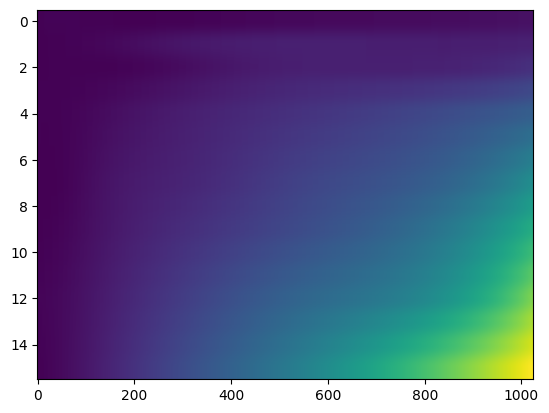

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json

with open("estimator_arrays/est_store_bge_m3.txt", "r") as f:
    estimators = np.array(json.load(f), dtype=np.int64)

plt.imshow(estimators)
plt.axis('auto')	
plt.show()

In [2]:
SIM_SEED = 42
N_USERS = 16
TOTAL_REQUESTS = 10_000
MIN_TOKENS = 1
MAX_TOKENS = 1000

print("Simulation config:")
print("  seed:", SIM_SEED)
print("  n_users / max_queue_size:", N_USERS)
print("  total_requests:", TOTAL_REQUESTS)


Simulation config:
  seed: 42
  n_users / max_queue_size: 16
  total_requests: 10000


In [3]:
from optimal_batching import get_batch_start_end_idx_and_duration

def simulate_strategy(
    *,
    estimators: np.ndarray,
    strategy: str,
    seed: int,
    n_users: int,
    total_requests: int,
    min_tokens: int,
    max_tokens: int,
) -> dict:
    """Run one scheduler simulation with queue refill each loop and a single simulation clock."""
    rng = np.random.default_rng(seed)

    max_queue_size = n_users
    queue: list[tuple[int, int]] = []  # (arrival_time_ms, token_count)

    generated_requests = 0
    current_time = 0
    completed_latencies: list[int] = []
    completed_batch_sizes: list[int] = []

    while len(completed_latencies) < total_requests:
        # Refill at loop start: create only enough requests to fill queue capacity.
        requests_to_add = min(max_queue_size - len(queue), total_requests - generated_requests)
        for _ in range(requests_to_add):
            token_count = int(rng.integers(min_tokens, max_tokens + 1))
            queue.append((current_time, token_count))
            generated_requests += 1

        if not queue:
            break

        queue.sort(key=lambda x: x[1])  # sort by token_count for DP batching assumptions
        arrival_times, model_input_sizes = zip(*queue)
        start_idx, end_idx, process_duration = get_batch_start_end_idx_and_duration(
            model_input_sizes,
            estimators,
            arrival_times,
            current_time,
            strategy,
        )
        current_time += process_duration
        for arrival_time, _ in queue[start_idx:end_idx]:
            completed_latencies.append(current_time - arrival_time)

        completed_batch_sizes.append(end_idx-start_idx)
        del queue[start_idx:end_idx]

    lat = np.array(completed_latencies, dtype=np.float64)/1e9
    bs = np.array(completed_batch_sizes, dtype=np.float64)
    print("FINAL TIME", current_time)
    return {
        "throughput": round(total_requests / (current_time/1e9), 3),
        "strategy": strategy,
        "requests": int(len(lat)),
        "mean_latency_s": float(lat.mean()),
        "p95_latency_s": float(np.percentile(lat, 95)),
        "max_latency_s": float(lat.max()),
        "mean_batch_size": float(bs.mean()),
        "batches": int(len(bs)),
    }


strategies = ["RMS", "FIFO", "MINMAX", "MEANMAX", "MINMAX_GUARDED_RMSE", "EFFICIENCY", "BATCH_SIZE", "SRPT_AGING", "HRRN", "THROUGHPUT_AGING"]
results = [
    simulate_strategy(
        estimators=estimators,
        strategy=strategy,
        seed=SIM_SEED,
        n_users=N_USERS,
        total_requests=TOTAL_REQUESTS,
        min_tokens=MIN_TOKENS,
        max_tokens=MAX_TOKENS,
    )
    for strategy in strategies
]
results.sort(key=lambda x: x["mean_batch_size"])
results


FINAL TIME 278940608880
FINAL TIME 265098013008
FINAL TIME 267696916111
FINAL TIME 267856528209
FINAL TIME 272264752913
FINAL TIME 260956452389
FINAL TIME 272552138360
FINAL TIME 321424122370
FINAL TIME 267455329116
FINAL TIME 265407445212


[{'throughput': 31.112,
  'strategy': 'SRPT_AGING',
  'requests': 10000,
  'mean_latency_s': 0.5137805884159999,
  'p95_latency_s': 0.4328531863499998,
  'max_latency_s': 297.776840572,
  'mean_batch_size': 1.5659254619480112,
  'batches': 6386},
 {'throughput': 37.389,
  'strategy': 'HRRN',
  'requests': 10000,
  'mean_latency_s': 0.42762120721969993,
  'p95_latency_s': 0.999968232,
  'max_latency_s': 1.822477646,
  'mean_batch_size': 3.1565656565656566,
  'batches': 3168},
 {'throughput': 35.85,
  'strategy': 'RMS',
  'requests': 10000,
  'mean_latency_s': 0.44590527794869994,
  'p95_latency_s': 1.3810579971999997,
  'max_latency_s': 4.440508196,
  'mean_batch_size': 3.7864445285876562,
  'batches': 2641},
 {'throughput': 37.333,
  'strategy': 'MEANMAX',
  'requests': 10000,
  'mean_latency_s': 0.4282098977895001,
  'p95_latency_s': 0.7919496908,
  'max_latency_s': 1.350745874,
  'mean_batch_size': 3.84172109104879,
  'batches': 2603},
 {'throughput': 36.729,
  'strategy': 'MINMAX_GU

In [4]:
def print_results_table(results: list[dict]) -> None:
    headers = ["strategy", "requests", "throughput", "mean_latency_s", "p95_latency_s", "max_latency_s", "mean_batch_size", "batches"]
    row_format = "{:<20} {:>8} {:>16} {:>16} {:>15} {:>16} {:>8}"

    print(row_format.format(*headers))
    print("-" * 100)
    for r in results:
        print(
            row_format.format(
                r["strategy"],
                r["requests"],
                r["throughput"],
                f"{r['mean_latency_s']:.2f}",
                f"{r['p95_latency_s']:.2f}",
                f"{r['max_latency_s']:.2f}",
                f"{r['mean_batch_size']:.2f}",
                r["batches"],
            )
        )

print_results_table(results)


strategy             requests       throughput   mean_latency_s   p95_latency_s    max_latency_s mean_batch_size
----------------------------------------------------------------------------------------------------
SRPT_AGING              10000           31.112             0.51            0.43           297.78     1.57
HRRN                    10000           37.389             0.43            1.00             1.82     3.16
RMS                     10000            35.85             0.45            1.38             4.44     3.79
MEANMAX                 10000           37.333             0.43            0.79             1.35     3.84
MINMAX_GUARDED_RMSE     10000           36.729             0.44            1.10             2.48     3.90
THROUGHPUT_AGING        10000           37.678             0.42            0.82             1.33     3.97
FIFO                    10000           37.722             0.42            0.79             1.12     4.00
MINMAX                  10000           37.3

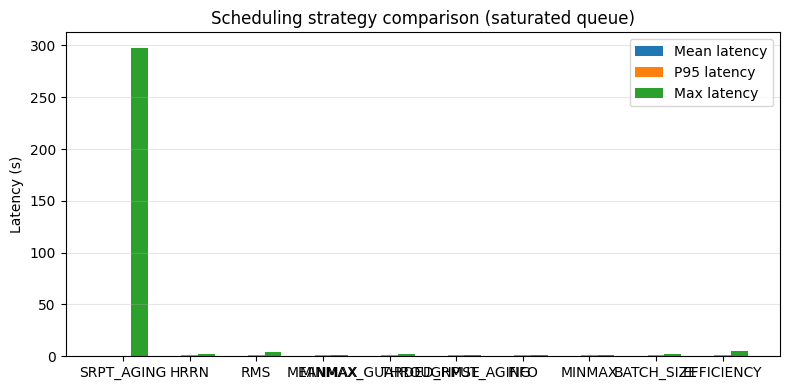

In [5]:
import numpy as np
import matplotlib.pyplot as plt

labels = [r["strategy"] for r in results]
means = [r["mean_latency_s"] for r in results]
p95 = [r["p95_latency_s"] for r in results]
max_latency = [r["max_latency_s"] for r in results]

x = np.arange(len(labels))
width = 0.25  # slightly smaller so 3 bars fit nicely

fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(x - width, means, width, label="Mean latency")
ax.bar(x, p95, width, label="P95 latency")
ax.bar(x + width, max_latency, width, label="Max latency")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Latency (s)")
ax.set_title("Scheduling strategy comparison (saturated queue)")

ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()
